# 7. Визуализация: от EVT-сигнала к начальному источнику

**Цель:** на многоканальном ряде показать одной проверяемой фигурой (1) индикатор и POT/GPD-порог, (2) момент устойчивого EVT-превышения, (3) отклики каналов рядом с ним и (4) ранжирование предполагаемого начального источника. Красный столбец — оценка модели, а не доказанная причинность.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from graph_evt_agent import EVTConfig, GraphConfig, GraphEVTPipeline, InputConfig

# Make the local src-layout package importable when the notebook is opened
# directly in VS Code/Jupyter, without requiring an editable installation.
candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / "demo/evt-educational-demo"]
ROOT = next(
    (path for path in candidates if (path / "data/generated/kuramoto_synchronized_series.csv").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Cannot find the demo root. Open this notebook from the repository or demo directory."
    )
src_path = str(ROOT / "src")
if src_path not in sys.path:
    sys.path.append(src_path)

from evt_demo.visualization import plot_evt_source_result

DATA = ROOT / "data/generated/kuramoto_synchronized_series.csv"
SEED = 42
df = pd.read_csv(DATA)
channel_names = [column for column in df if column.startswith("channel_")]
x = df[channel_names].to_numpy()
assert np.isfinite(x).all() and x.ndim == 2

In [2]:
BASELINE_SIZE = 300
pipeline = GraphEVTPipeline(
    EVTConfig(baseline_size=BASELINE_SIZE, tail_quantile=0.90, alarm_probability=0.99, persistence=2),
    graph=GraphConfig(random_state=SEED),
    input_config=InputConfig(missing="error"),
    verbose=True,
)
result = pipeline.run_detailed(x)
assert result.detection.detected and result.ranking is not None
{"detected_at": result.detection.time_index, "estimated_source": channel_names[result.ranking.source], "probability": float(result.ranking.probabilities[0])}

Graph-EVT pipeline:   0%|          | 0/5 [00:00<?, ?it/s]

{'detected_at': 300,
 'estimated_source': 'channel_08',
 'probability': 0.9729195275010182}

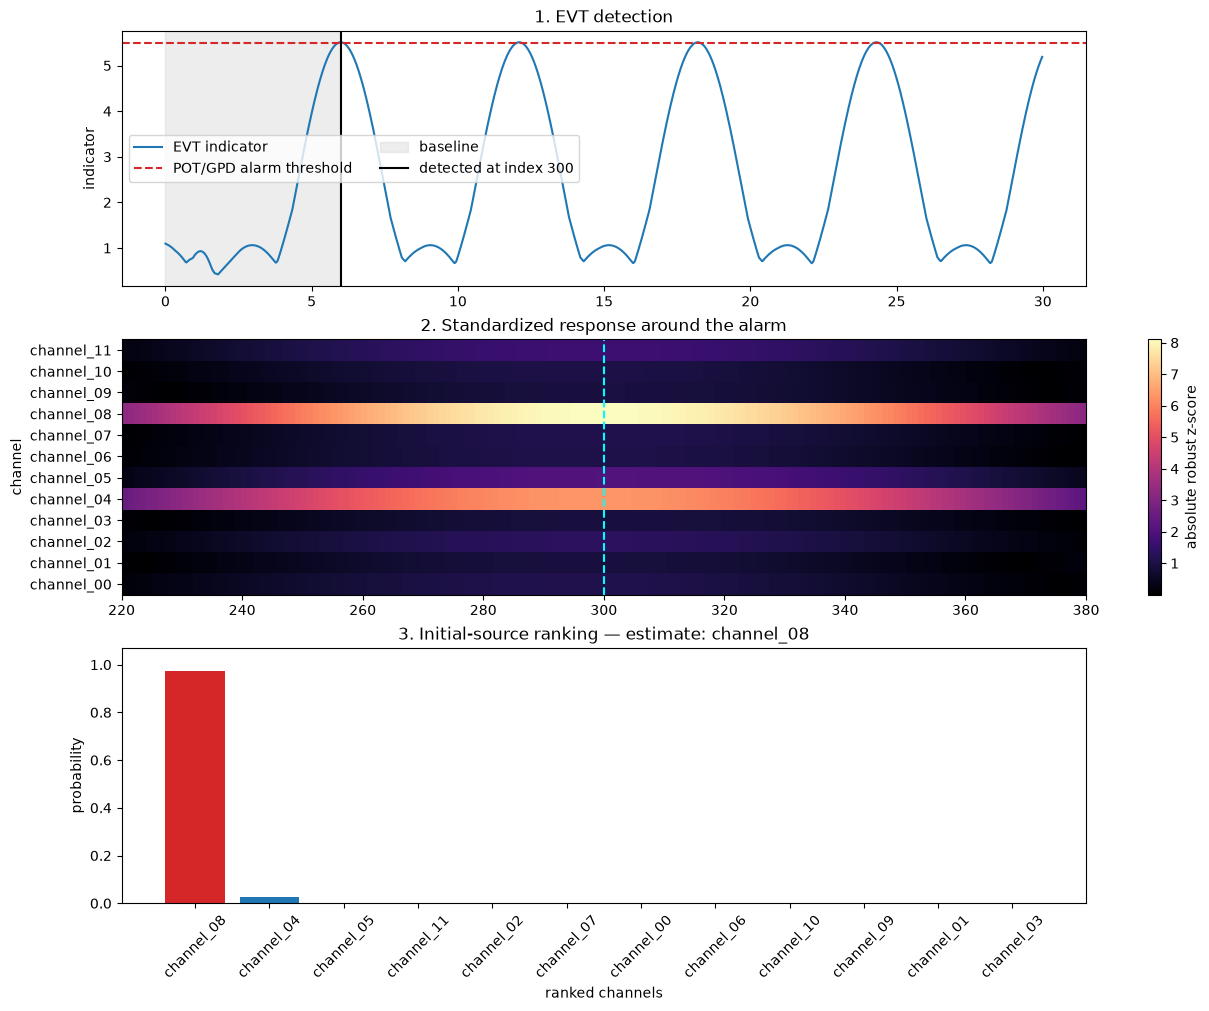

In [3]:
figure, axes = plot_evt_source_result(
    x, result, timestamps=df["timestamp"].to_numpy(), channel_names=channel_names,
    baseline_size=BASELINE_SIZE, context=80, output_path=ROOT / "figures/n-d/evt_source_result.png",
)

На верхней панели пересечение синего индикатора с красным порогом объясняет детекцию. Тепловая карта показывает нормированные реакции, использованные после тревоги. Нижняя панель показывает **всё распределение** рейтинга: первый узел — оценённый исходный источник. В метаданных генератора номинальный frequency-lead задан отдельно; несовпадение с ranking следует обсуждать как ошибку/ограничение локализации, а не скрывать.